In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print("Libraries imported successfully")

Libraries imported successfully


In [42]:
url = "https://raw.githubusercontent.com/rajatg1989/MLOPS/main/taxis_data.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully")

Dataset loaded successfully


In [65]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows Before Cleaning:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicate Rows Removed")
print("New Shape:", df.shape)

Dataset Shape:
(6341, 16)

First 5 Rows:


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,trip_duration,pickup_hour
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000,17
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333,13



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 6341 entries, 0 to 6432
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6341 non-null   datetime64[ns]
 1   dropoff          6341 non-null   datetime64[ns]
 2   passengers       6341 non-null   int64         
 3   distance         6341 non-null   float64       
 4   fare             6341 non-null   float64       
 5   tip              6341 non-null   float64       
 6   tolls            6341 non-null   float64       
 7   total            6341 non-null   float64       
 8   color            6341 non-null   object        
 9   payment          6341 non-null   object        
 10  pickup_zone      6341 non-null   object        
 11  dropoff_zone     6341 non-null   object        
 12  pickup_borough   6341 non-null   object        
 13  dropoff_borough  6341 non-null   object        
 14  trip_duration    6341 n

In [44]:
df = df.dropna()

print("Null values removed")
print(df.shape)

Null values removed
(6341, 14)


In [45]:
df['pickup'] = pd.to_datetime(df['pickup'])
df['dropoff'] = pd.to_datetime(df['dropoff'])

print("Date columns converted")

Date columns converted


In [46]:
df['trip_duration'] = (
    df['dropoff'] - df['pickup']
).dt.total_seconds() / 60

print("Trip duration column created")

display(df[['pickup', 'dropoff', 'trip_duration']].head())

Trip duration column created


,pickup,dropoff,trip_duration
0,2019-03-23 20:21:09,2019-03-23 20:27:24,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,9.533333


In [47]:
df['pickup_hour'] = df['pickup'].dt.hour

print("Pickup hour feature created")

display(df[['pickup', 'pickup_hour']].head())

Pickup hour feature created


,pickup,pickup_hour
0,2019-03-23 20:21:09,20
1,2019-03-04 16:11:55,16
2,2019-03-27 17:53:01,17
3,2019-03-10 01:23:59,1
4,2019-03-30 13:27:42,13


In [48]:
df['pickup_hour'] = df['pickup'].dt.hour

print("Pickup hour feature created")

display(df[['pickup', 'pickup_hour']].head())

Pickup hour feature created


,pickup,pickup_hour
0,2019-03-23 20:21:09,20
1,2019-03-04 16:11:55,16
2,2019-03-27 17:53:01,17
3,2019-03-10 01:23:59,1
4,2019-03-30 13:27:42,13


In [49]:
print("Maximum Fare:")
print(df['fare'].max())

print("\nAverage Distance:")
print(df['distance'].mean())

print("\nAverage Trip Duration:")
print(df['trip_duration'].mean())

Maximum Fare:
150.0

Average Distance:
2.9977069862797663

Average Trip Duration:
14.349182568469745


In [50]:
print("Payment Counts:")
print(df['payment'].value_counts())

print("\nAverage Fare by Payment:")
print(df.groupby('payment')['fare'].mean())

Payment Counts:
payment
credit card    4546
cash           1795
Name: count, dtype: int64

Average Fare by Payment:
payment
cash           11.259053
credit card    13.531098
Name: fare, dtype: float64


In [51]:
print("Payment Counts:")
print(df['payment'].value_counts())

print("\nAverage Fare by Payment:")
print(df.groupby('payment')['fare'].mean())

Payment Counts:
payment
credit card    4546
cash           1795
Name: count, dtype: int64

Average Fare by Payment:
payment
cash           11.259053
credit card    13.531098
Name: fare, dtype: float64


In [52]:
summary = (
    df.groupby('payment')
    .agg(
        avg_fare=('fare', 'mean'),
        avg_tip=('tip', 'mean'),
        avg_distance=('distance', 'mean'),
        total_trips=('fare', 'count')
    )
)

print(summary)

              avg_fare  avg_tip  avg_distance  total_trips
payment                                                   
cash         11.259053  0.00000      2.461760         1795
credit card  13.531098  2.75163      3.209327         4546


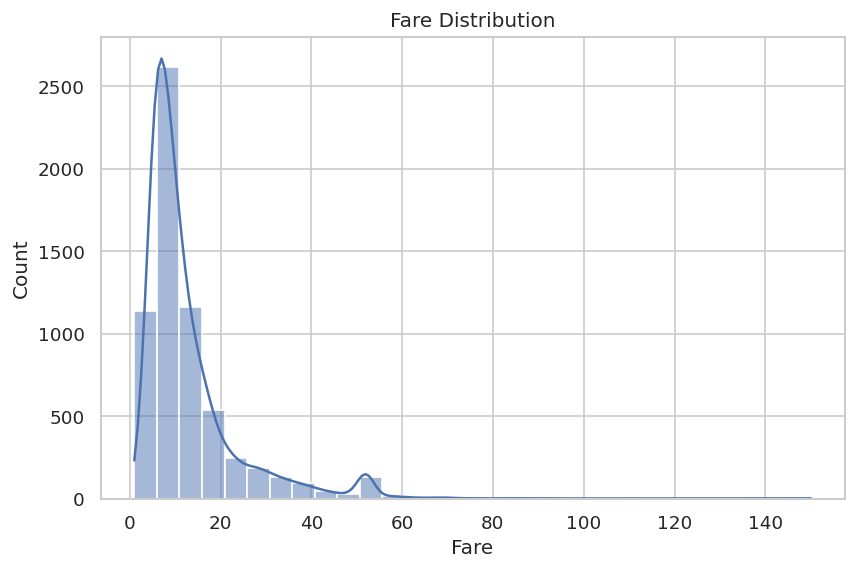

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['fare'],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

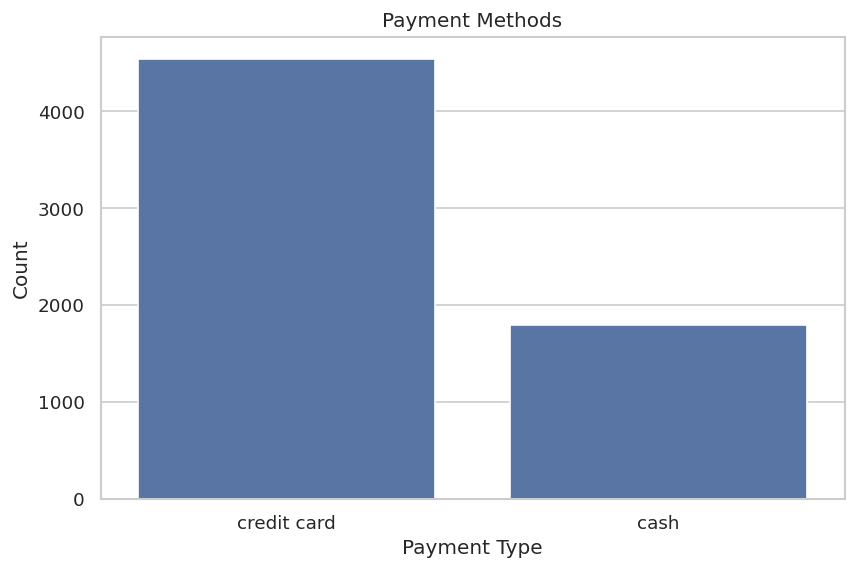

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='payment',
    data=df
)

plt.title("Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()

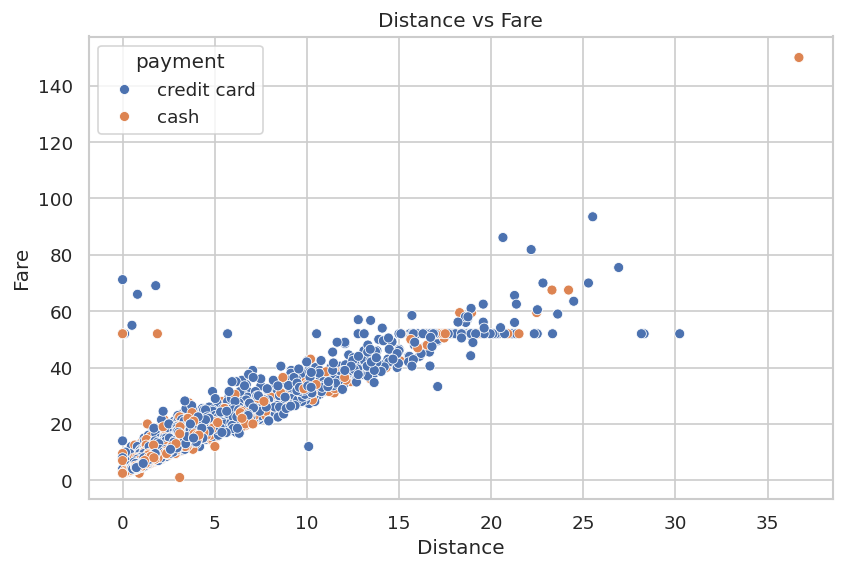

In [55]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='distance',
    y='fare',
    hue='payment',
    data=df
)

plt.title("Distance vs Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.show()

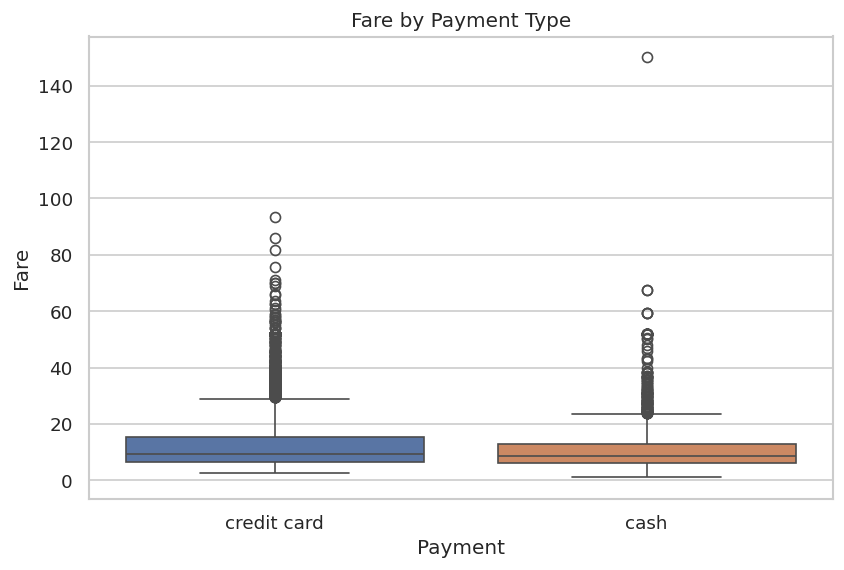

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='payment',
    y='fare',
    hue='payment',
    data=df,
    legend=False
)

plt.title("Fare by Payment Type")
plt.xlabel("Payment")
plt.ylabel("Fare")

plt.show()

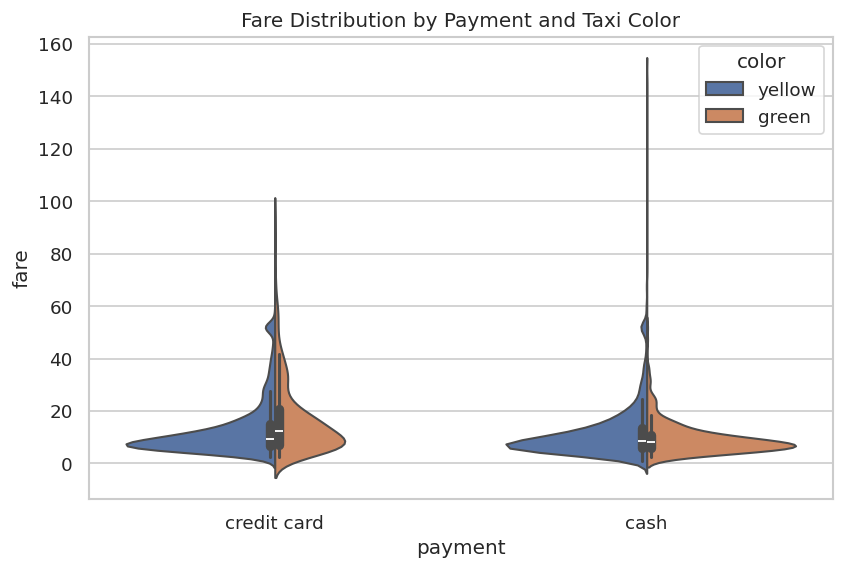

In [58]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='payment',
    y='fare',
    hue='color',
    split=True
)

plt.title("Fare Distribution by Payment and Taxi Color")

plt.show()

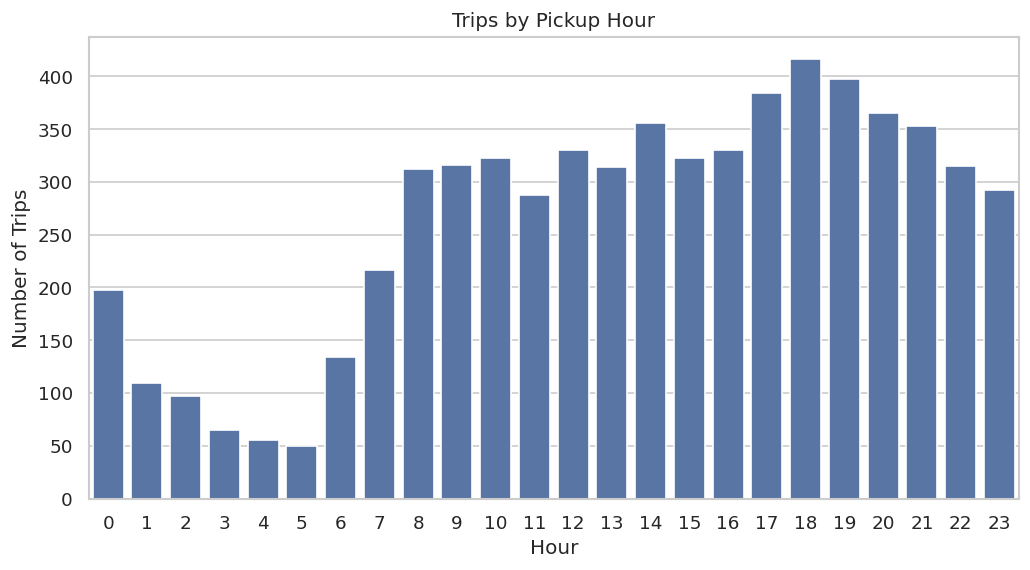

In [60]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='pickup_hour',
    data=df
)

plt.title("Trips by Pickup Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")

plt.show()

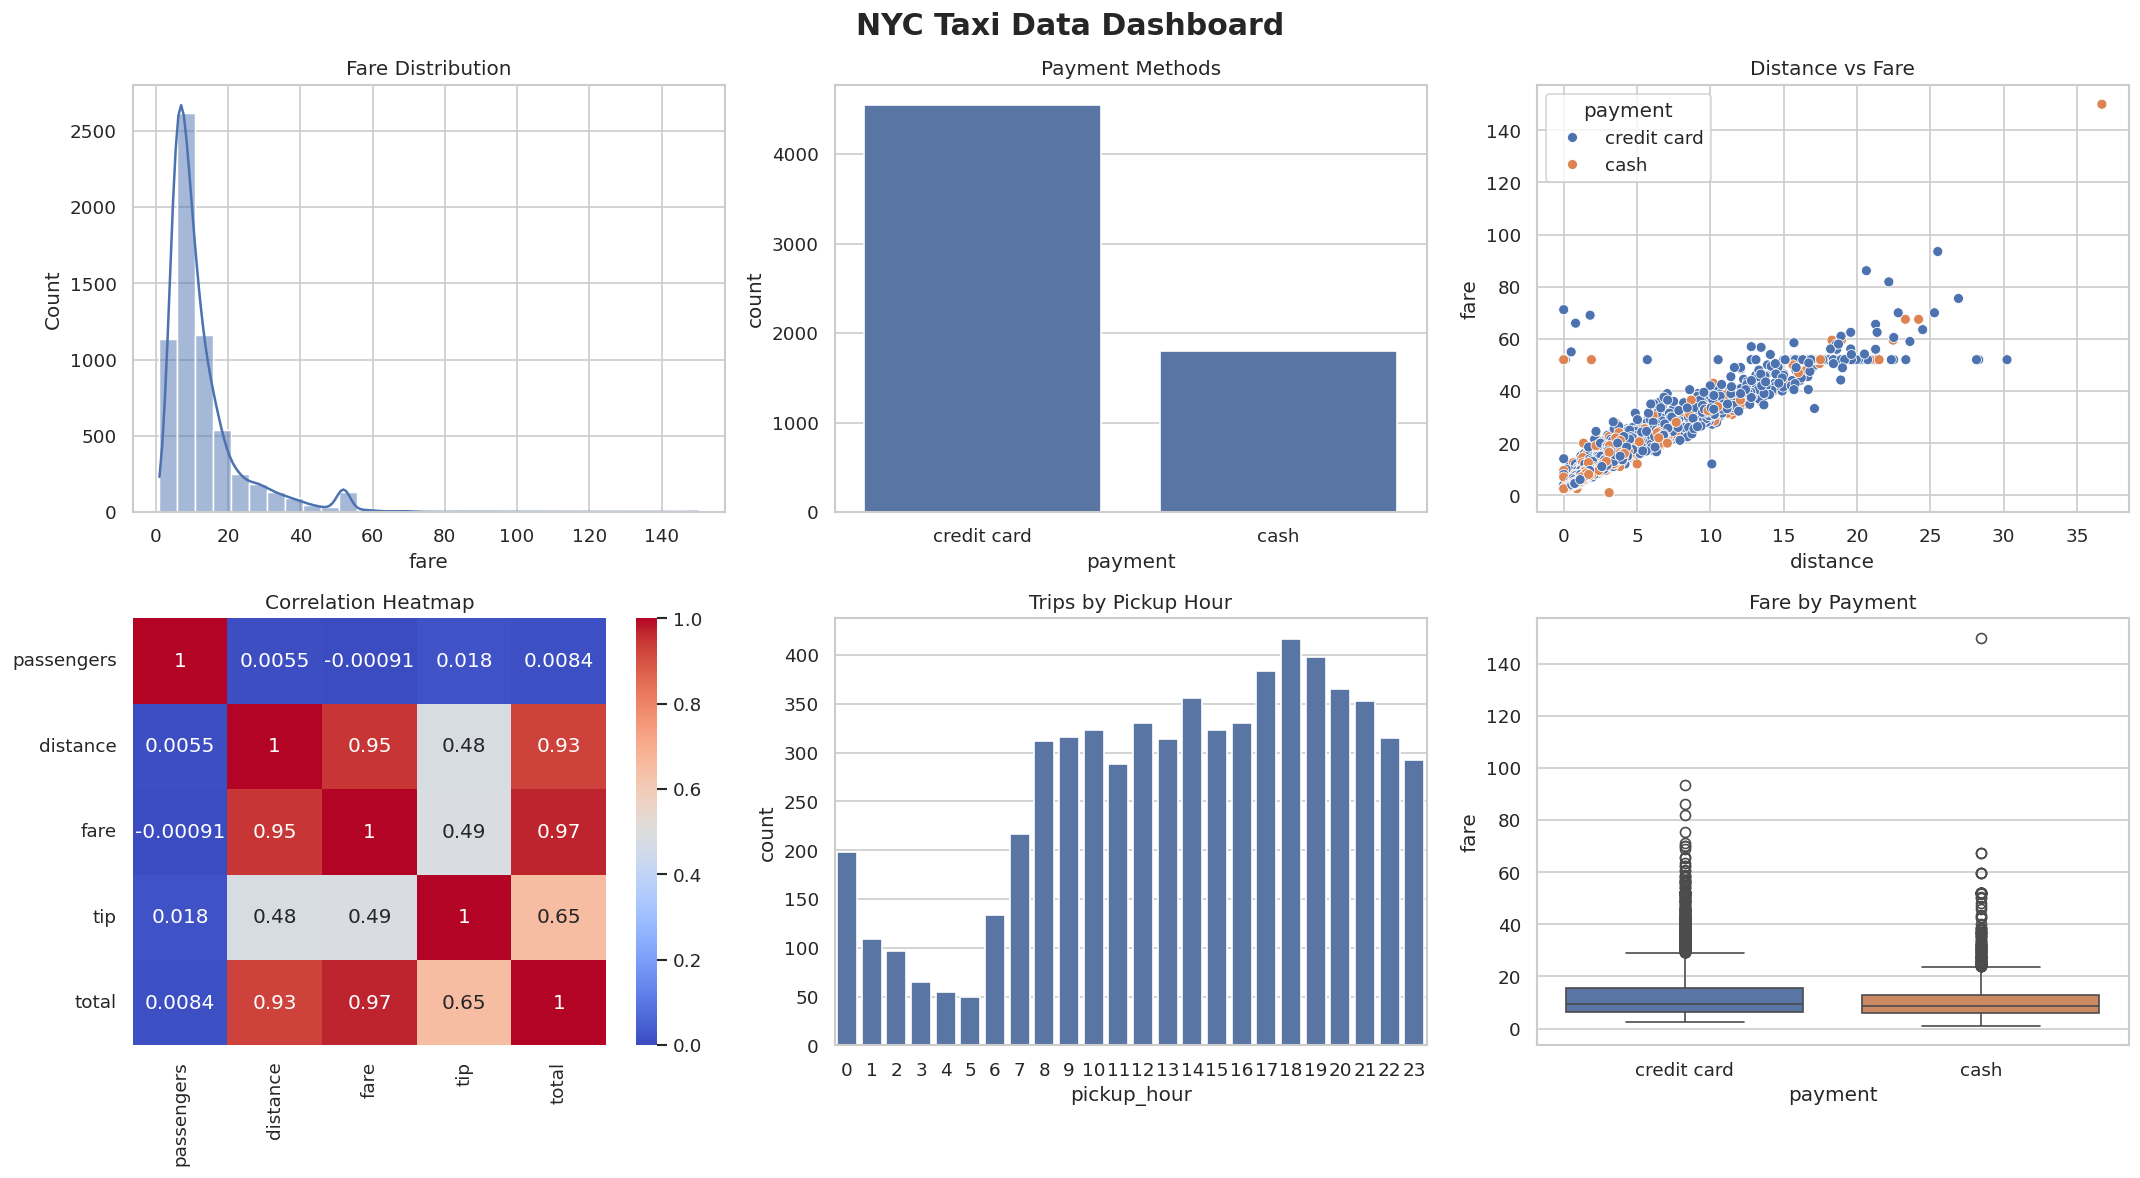

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

fig.suptitle(
    "NYC Taxi Data Dashboard",
    fontsize=18,
    fontweight='bold'
)

# Panel 1
sns.histplot(
    df['fare'],
    bins=30,
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title("Fare Distribution")


# Panel 2
sns.countplot(
    x='payment',
    data=df,
    ax=axes[0,1]
)

axes[0,1].set_title("Payment Methods")


# Panel 3
sns.scatterplot(
    x='distance',
    y='fare',
    hue='payment',
    data=df,
    ax=axes[0,2]
)

axes[0,2].set_title("Distance vs Fare")


# Panel 4
corr = df[
    [
        'passengers',
        'distance',
        'fare',
        'tip',
        'total'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[1,0]
)

axes[1,0].set_title("Correlation Heatmap")


# Panel 5
sns.countplot(
    x='pickup_hour',
    data=df,
    ax=axes[1,1]
)

axes[1,1].set_title("Trips by Pickup Hour")


# Panel 6
sns.boxplot(
    x='payment',
    y='fare',
    hue='payment',
    data=df,
    legend=False,
    ax=axes[1,2]
)

axes[1,2].set_title("Fare by Payment")


plt.tight_layout()

plt.savefig("taxi_dashboard.png")

plt.show()

# Narrative Conclusion

This capstone project analyzed NYC taxi trip data
using Pandas, NumPy, Matplotlib, and Seaborn.

The project included:
- Data Cleaning
- Feature Engineering
- Statistical Analysis
- Exploratory Data Analysis
- Dashboard Visualization

The analysis explored:
- payment behavior
- fare distribution
- trip duration trends
- borough activity
- pickup hour patterns

Key insights showed that:
- credit card payments dominate taxi transactions
- fare increases with trip distance
- peak taxi demand occurs during evening hours
- trip cost strongly depends on distance and tolls

The dashboard successfully summarized taxi operations,
passenger behavior, payment trends, and fare patterns.

This project demonstrates practical skills in:
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Statistical Analysis
- Data Visualization
- Business Insight Generation